In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
plt.style.use("default")
sns.set(font_scale=1.1)

In [2]:
df=pd.read_csv("transactions.csv")
df

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15T17:00:04Z,397.40,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17T01:27:31Z,935.28,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299690,299691,6000,996,45,27.93,34.07,ES,ES,web,grocery,0,1,1,0,2024-09-29T04:40:54Z,218.55,0
299691,299692,6000,996,45,27.93,68.56,ES,ES,app,travel,0,1,1,1,2024-10-03T08:49:02Z,185.55,0
299692,299693,6000,996,45,27.93,25.02,ES,ES,app,fashion,0,1,1,1,2024-10-26T07:40:38Z,33.50,0
299693,299694,6000,996,45,27.93,23.92,ES,ES,web,gaming,0,0,0,0,2024-10-27T09:31:56Z,71.75,0


In [3]:
df.tail(10)

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
299685,299686,6000,996,45,27.93,14.77,ES,ES,web,gaming,0,1,1,1,2024-07-22T17:38:36Z,248.33,0
299686,299687,6000,996,45,27.93,22.82,ES,ES,web,fashion,0,1,1,1,2024-07-28T19:01:37Z,330.82,0
299687,299688,6000,996,45,27.93,33.97,ES,ES,app,electronics,0,1,0,1,2024-08-13T18:10:39Z,250.45,0
299688,299689,6000,996,45,27.93,22.42,ES,ES,web,electronics,0,1,1,0,2024-09-13T12:55:26Z,293.42,0
299689,299690,6000,996,45,27.93,100.16,ES,ES,app,travel,0,1,1,1,2024-09-27T21:39:47Z,424.14,0
299690,299691,6000,996,45,27.93,34.07,ES,ES,web,grocery,0,1,1,0,2024-09-29T04:40:54Z,218.55,0
299691,299692,6000,996,45,27.93,68.56,ES,ES,app,travel,0,1,1,1,2024-10-03T08:49:02Z,185.55,0
299692,299693,6000,996,45,27.93,25.02,ES,ES,app,fashion,0,1,1,1,2024-10-26T07:40:38Z,33.50,0
299693,299694,6000,996,45,27.93,23.92,ES,ES,web,gaming,0,0,0,0,2024-10-27T09:31:56Z,71.75,0
299694,299695,6000,996,45,27.93,26.07,ES,ES,web,gaming,1,1,1,1,2024-10-30T11:10:23Z,355.83,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299695 entries, 0 to 299694
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           299695 non-null  int64  
 1   user_id                  299695 non-null  int64  
 2   account_age_days         299695 non-null  int64  
 3   total_transactions_user  299695 non-null  int64  
 4   avg_amount_user          299695 non-null  float64
 5   amount                   299695 non-null  float64
 6   country                  299695 non-null  object 
 7   bin_country              299695 non-null  object 
 8   channel                  299695 non-null  object 
 9   merchant_category        299695 non-null  object 
 10  promo_used               299695 non-null  int64  
 11  avs_match                299695 non-null  int64  
 12  cvv_result               299695 non-null  int64  
 13  three_ds_flag            299695 non-null  int64  
 14  tran

In [5]:
target_col='is_fraud'
numeric_col=['transaction_id','user_id','account_age_days','total_transactions_user','avg_amount_user','amount','promo_used','avs_match','cvv_result','three_ds_flag','shipping_distance_km']
categorical_col=['country','bin_country','channel','merchant_category','transaction_time']
print(target_col)
print(numeric_col)
print(categorical_col)

is_fraud
['transaction_id', 'user_id', 'account_age_days', 'total_transactions_user', 'avg_amount_user', 'amount', 'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag', 'shipping_distance_km']
['country', 'bin_country', 'channel', 'merchant_category', 'transaction_time']


In [6]:
df.isnull().sum()

transaction_id             0
user_id                    0
account_age_days           0
total_transactions_user    0
avg_amount_user            0
amount                     0
country                    0
bin_country                0
channel                    0
merchant_category          0
promo_used                 0
avs_match                  0
cvv_result                 0
three_ds_flag              0
transaction_time           0
shipping_distance_km       0
is_fraud                   0
dtype: int64

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_id,299695.0,149848.000000,86514.638800,1.00,74924.50,149848.00,224771.50,299695.00
user_id,299695.0,3002.559432,1732.309663,1.00,1501.00,3007.00,4504.00,6000.00
account_age_days,299695.0,973.397871,525.241409,1.00,516.00,975.00,1425.00,1890.00
total_transactions_user,299695.0,50.673321,5.976391,40.00,46.00,51.00,56.00,60.00
avg_amount_user,299695.0,148.142973,200.364624,3.52,46.19,90.13,173.45,4565.29
amount,299695.0,177.165279,306.926507,1.00,42.10,89.99,191.11,16994.74
promo_used,299695.0,0.153640,0.360603,0.00,0.00,0.00,0.00,1.00
avs_match,299695.0,0.837999,0.368453,0.00,1.00,1.00,1.00,1.00
cvv_result,299695.0,0.872110,0.333968,0.00,1.00,1.00,1.00,1.00
three_ds_flag,299695.0,0.784588,0.411109,0.00,1.00,1.00,1.00,1.00


In [8]:
df[numeric_col].agg(['min','max','mean','median']).T

,min,max,mean,median
transaction_id,1.00,299695.00,149848.000000,149848.00
user_id,1.00,6000.00,3002.559432,3007.00
account_age_days,1.00,1890.00,973.397871,975.00
total_transactions_user,40.00,60.00,50.673321,51.00
avg_amount_user,3.52,4565.29,148.142973,90.13
amount,1.00,16994.74,177.165279,89.99
promo_used,0.00,1.00,0.153640,0.00
avs_match,0.00,1.00,0.837999,1.00
cvv_result,0.00,1.00,0.872110,1.00
three_ds_flag,0.00,1.00,0.784588,1.00


In [9]:
for c in categorical_col:
    print(c,df[c].unique())


country ['FR' 'US' 'TR' 'PL' 'ES' 'IT' 'RO' 'GB' 'NL' 'DE']
bin_country ['FR' 'US' 'RO' 'ES' 'TR' 'DE' 'GB' 'IT' 'PL' 'NL']
channel ['web' 'app']
merchant_category ['travel' 'fashion' 'electronics' 'grocery' 'gaming']
transaction_time ['2024-01-06T04:09:39Z' '2024-01-09T20:13:47Z' '2024-01-12T06:20:11Z' ...
 '2024-10-26T07:40:38Z' '2024-10-27T09:31:56Z' '2024-10-30T11:10:23Z']


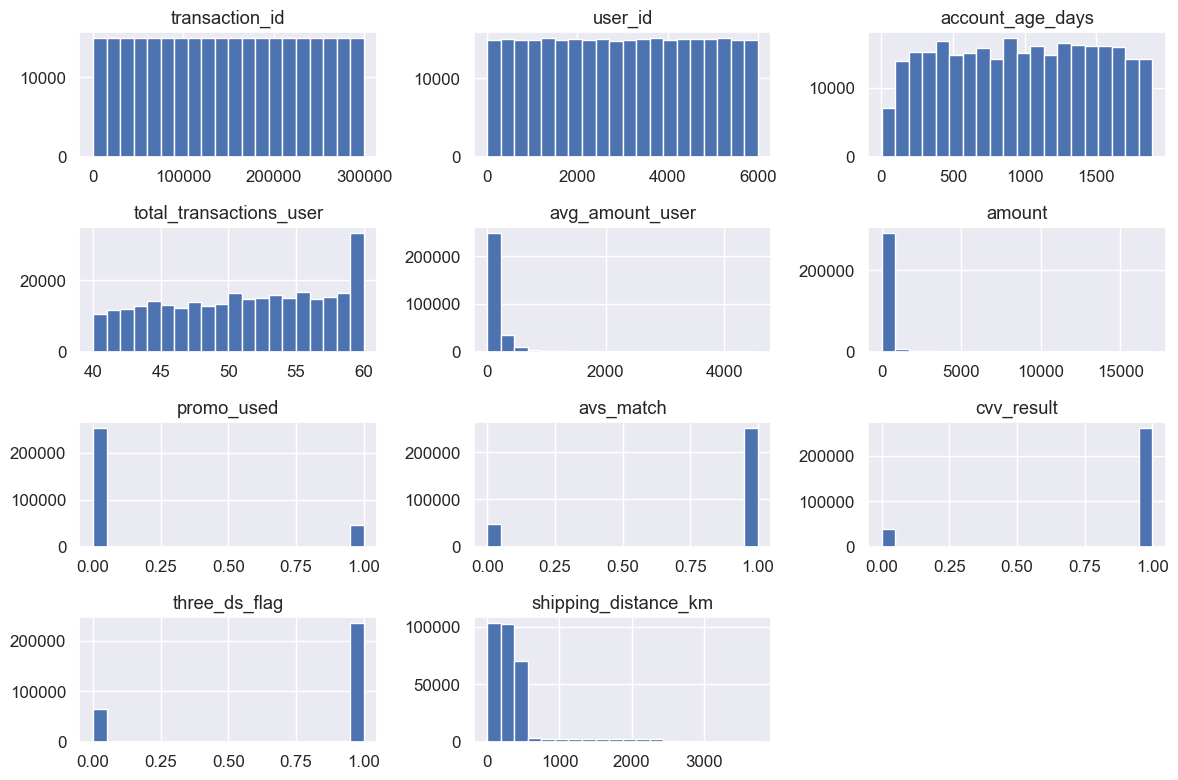

In [11]:
df[numeric_col].hist(bins=20,figsize=(12,8))
plt.title('Histrogram of Numerical Feature Age',fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
df[numeric_col].agg(['min','max','mean','median']).T

,min,max,mean,median
transaction_id,1.00,299695.00,149848.000000,149848.00
user_id,1.00,6000.00,3002.559432,3007.00
account_age_days,1.00,1890.00,973.397871,975.00
total_transactions_user,40.00,60.00,50.673321,51.00
avg_amount_user,3.52,4565.29,148.142973,90.13
amount,1.00,16994.74,177.165279,89.99
promo_used,0.00,1.00,0.153640,0.00
avs_match,0.00,1.00,0.837999,1.00
cvv_result,0.00,1.00,0.872110,1.00
three_ds_flag,0.00,1.00,0.784588,1.00


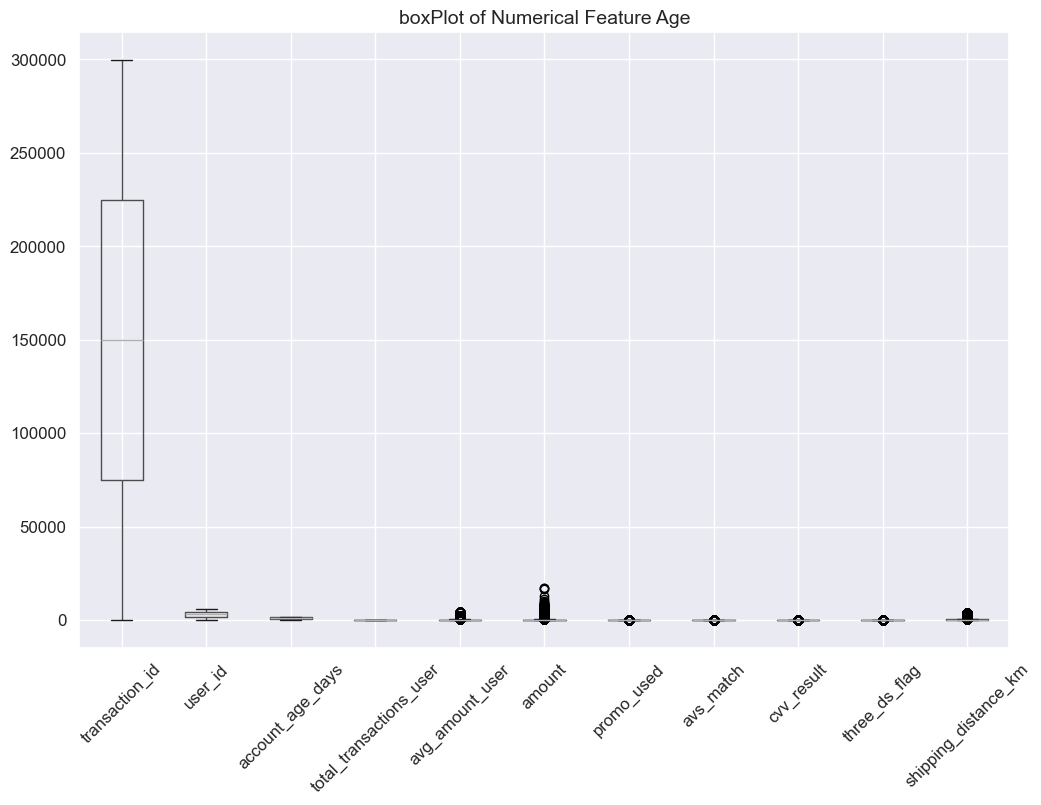

In [13]:
plt.figure(figsize=(12,8))
df[numeric_col].boxplot()
plt.title("boxPlot of Numerical Feature Age",fontsize=14)
plt.xticks(rotation=45)
plt.show()

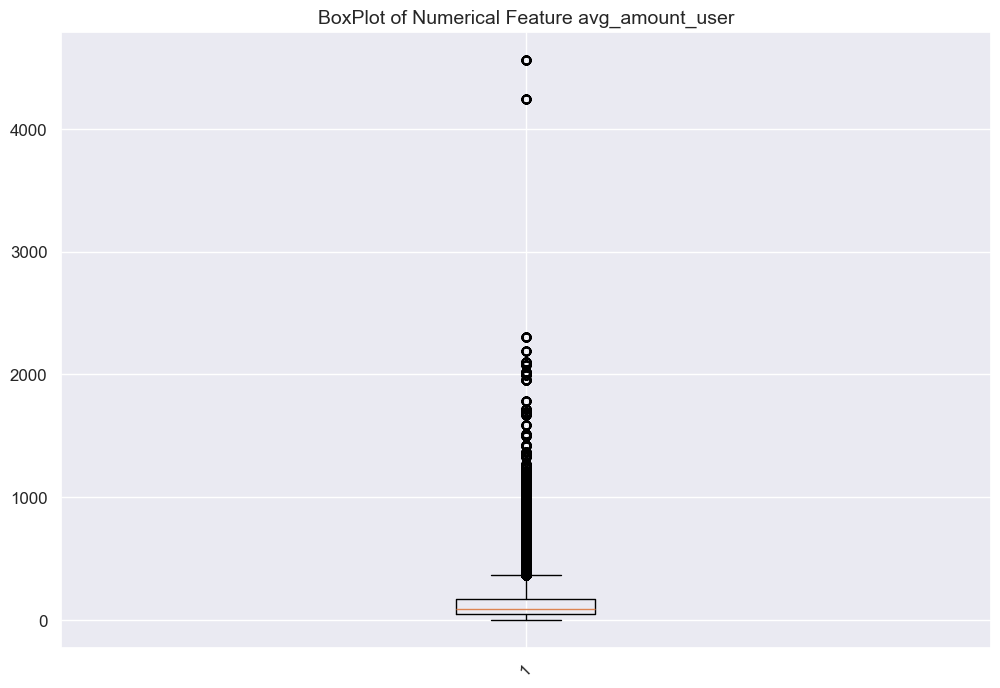

In [19]:
plt.figure(figsize=(12,8))
plt.boxplot(df['avg_amount_user'])
plt.title("BoxPlot of Numerical Feature avg_amount_user", fontsize=14)
plt.xticks(rotation=45)
plt.show()


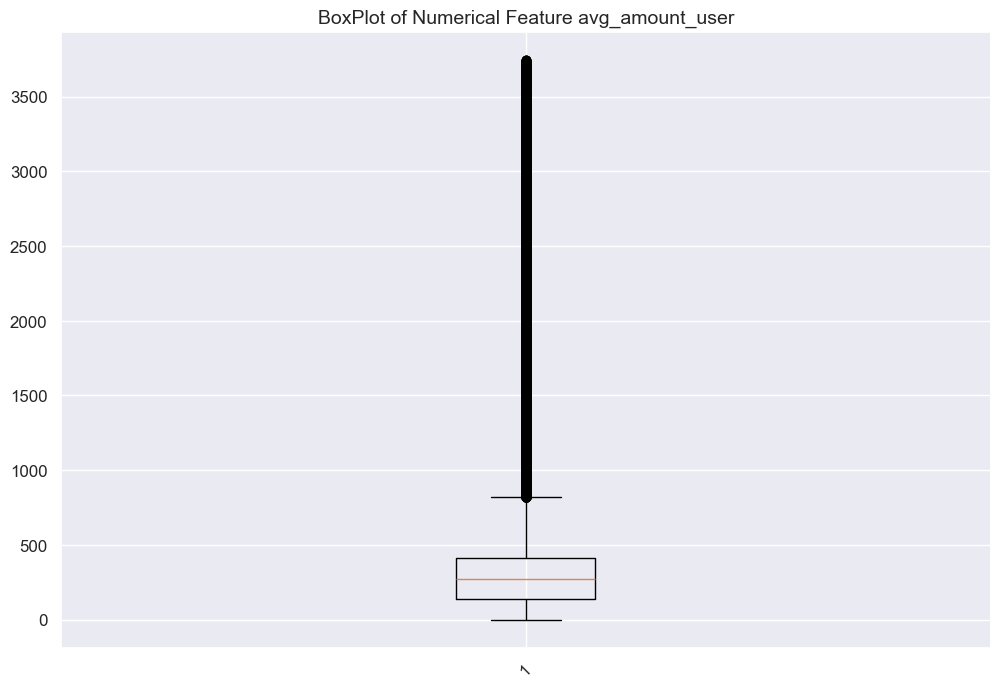

In [20]:
plt.figure(figsize=(12,8))
plt.boxplot(df['shipping_distance_km'])
plt.title("BoxPlot of Numerical Feature avg_amount_user", fontsize=14)
plt.xticks(rotation=45)
plt.show()

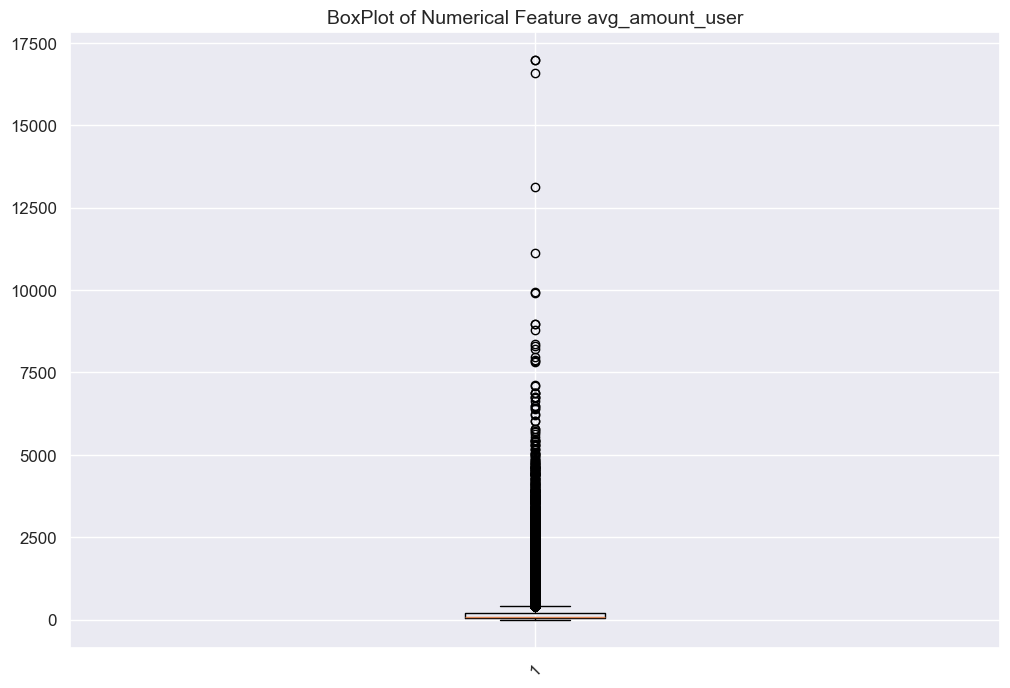

In [21]:
plt.figure(figsize=(12,8))
plt.boxplot(df['amount'])
plt.title("BoxPlot of Numerical Feature avg_amount_user", fontsize=14)
plt.xticks(rotation=45)
plt.show()

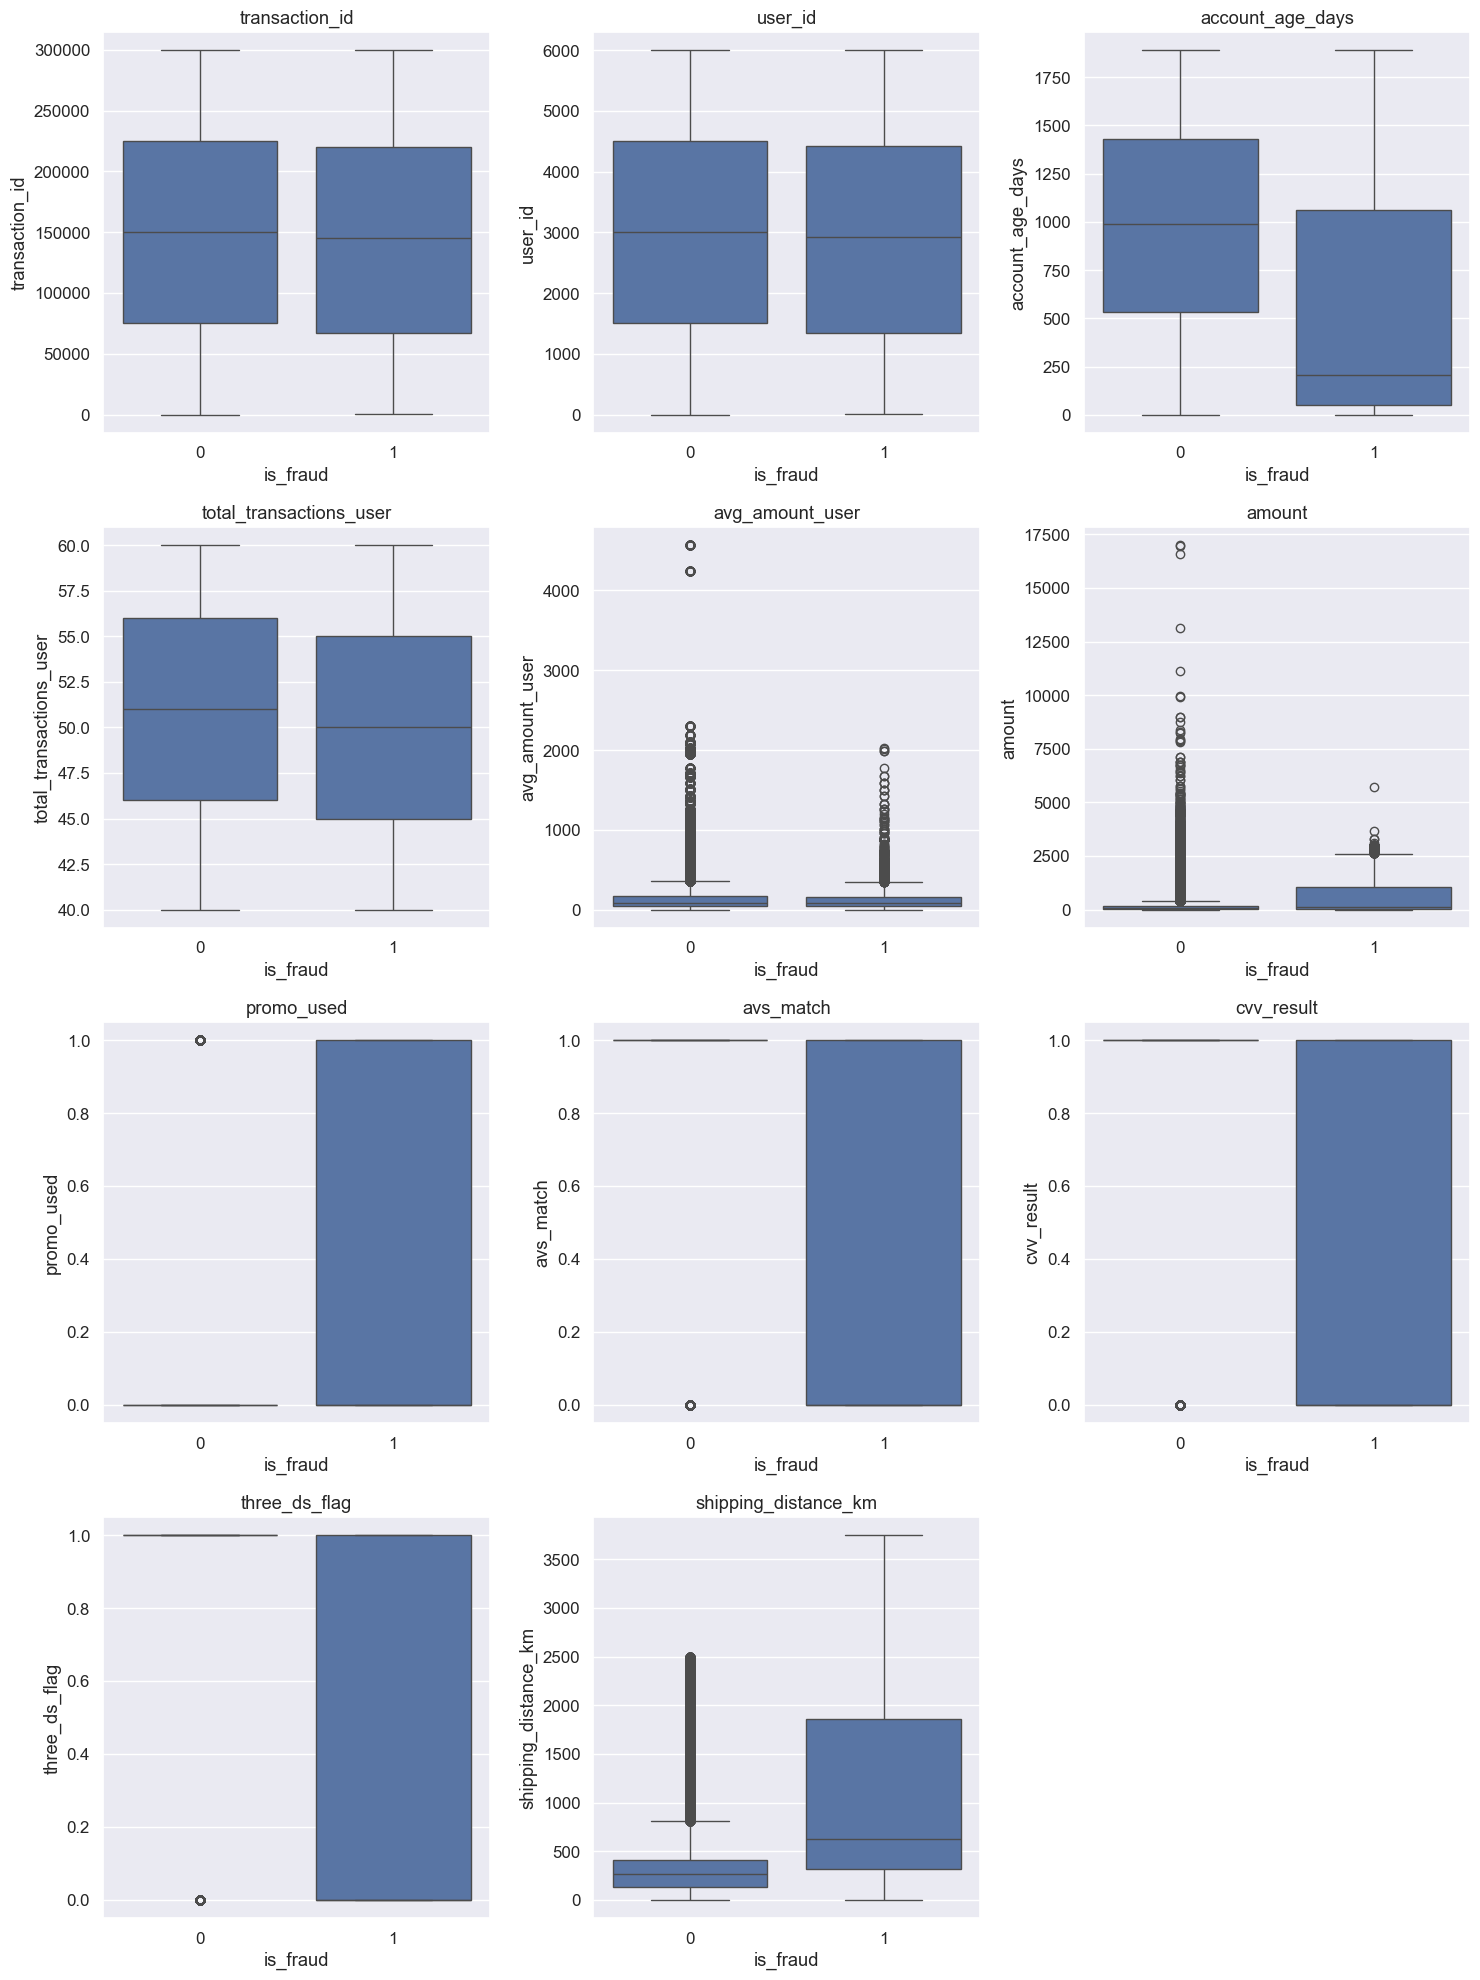

In [24]:
plt.figure(figsize=(15,20))

for i, col in enumerate(numeric_col, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x=df[target_col], y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()